In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

df = pd.read_csv("../AI_Hiring_Bias_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Libraries imported successfully!
Dataset loaded successfully!
Shape: (5000, 18)


In [2]:
df.head()

print("Column names:")

for column in df.columns:
    print(column)



Column names:
candidate_id
age
gender
education_level
university_tier
years_experience
employment_gap_months
technical_skill_score
communication_score
aptitude_test_score
coding_test_score
project_count
github_activity_score
certifications_count
expected_salary
ai_resume_score
ai_bias_score
hired


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   candidate_id           5000 non-null   str    
 1   age                    5000 non-null   int64  
 2   gender                 5000 non-null   str    
 3   education_level        5000 non-null   str    
 4   university_tier        5000 non-null   str    
 5   years_experience       5000 non-null   float64
 6   employment_gap_months  5000 non-null   float64
 7   technical_skill_score  5000 non-null   float64
 8   communication_score    5000 non-null   float64
 9   aptitude_test_score    5000 non-null   float64
 10  coding_test_score      5000 non-null   float64
 11  project_count          5000 non-null   int64  
 12  github_activity_score  5000 non-null   float64
 13  certifications_count   5000 non-null   int64  
 14  expected_salary        5000 non-null   int64  
 15  ai_resume_score

In [4]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
candidate_id             0
age                      0
gender                   0
education_level          0
university_tier          0
years_experience         0
employment_gap_months    0
technical_skill_score    0
communication_score      0
aptitude_test_score      0
coding_test_score        0
project_count            0
github_activity_score    0
certifications_count     0
expected_salary          0
ai_resume_score          0
ai_bias_score            0
hired                    0
dtype: int64


In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
candidate_id             0.0
age                      0.0
gender                   0.0
education_level          0.0
university_tier          0.0
years_experience         0.0
employment_gap_months    0.0
technical_skill_score    0.0
communication_score      0.0
aptitude_test_score      0.0
coding_test_score        0.0
project_count            0.0
github_activity_score    0.0
certifications_count     0.0
expected_salary          0.0
ai_resume_score          0.0
ai_bias_score            0.0
hired                    0.0
dtype: float64


In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

df.describe()

Number of duplicate rows: 0


,age,years_experience,employment_gap_months,technical_skill_score,communication_score,aptitude_test_score,coding_test_score,project_count,github_activity_score,certifications_count,expected_salary,ai_resume_score,ai_bias_score,hired
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,28.735800,4.34868,1.451140,68.950900,77.238960,58.044240,49.573080,4.123200,52.154920,1.983800,116908.200000,42.502800,43.005700,0.33000
std,4.753201,3.34593,2.260285,13.819627,10.420292,9.410153,13.330823,1.990682,14.876542,1.456833,39453.315267,7.244533,9.456575,0.47026
min,21.000000,0.00000,0.000000,30.000000,37.200000,30.000000,20.000000,0.000000,1.900000,0.000000,45000.000000,20.000000,20.000000,0.00000
25%,25.000000,1.80000,0.000000,59.300000,69.975000,51.600000,40.500000,3.000000,42.200000,1.000000,88500.000000,37.400000,36.400000,0.00000
50%,29.000000,3.80000,0.400000,68.900000,77.700000,58.000000,49.600000,4.000000,52.000000,2.000000,109900.000000,42.400000,42.800000,0.00000
75%,32.000000,6.10000,2.100000,78.500000,84.825000,64.600000,58.600000,5.000000,62.100000,3.000000,138000.000000,47.300000,49.400000,1.00000
max,51.000000,20.00000,16.700000,100.000000,100.000000,91.900000,95.600000,15.000000,100.000000,9.000000,280000.000000,70.400000,78.200000,1.00000


In [7]:
#Check for categorical values
print("Gender values:")
print(df["gender"].value_counts())

print("\nEducation levels:")
print(df["education_level"].value_counts())

print("\nUniversity tiers:")
print(df["university_tier"].value_counts())

print("\nHiring outcomes:")
print(df["hired"].value_counts())

Gender values:
gender
Male          2609
Female        2135
Non-Binary     256
Name: count, dtype: int64

Education levels:
education_level
Bachelor's    2858
Master's      1660
PhD            482
Name: count, dtype: int64

University tiers:
university_tier
Tier 2    2232
Tier 3    1764
Tier 1    1004
Name: count, dtype: int64

Hiring outcomes:
hired
0    3350
1    1650
Name: count, dtype: int64


In [8]:
#Check hiring percentages
hiring_percentage = df["hired"].value_counts(normalize=True) * 100

print(hiring_percentage)

hired
0    67.0
1    33.0
Name: proportion, dtype: float64


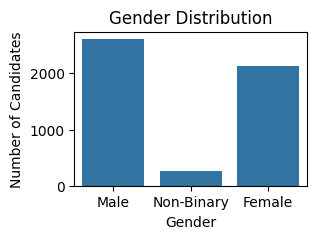

In [9]:
#Gender Distribution
plt.figure(figsize=(3,2))

sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Candidates")

plt.show()

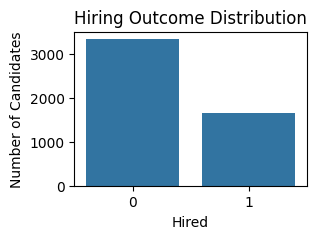

In [10]:
#Hiring Distribution
plt.figure(figsize=(3,2))

sns.countplot(data=df, x="hired")

plt.title("Hiring Outcome Distribution")
plt.xlabel("Hired")
plt.ylabel("Number of Candidates")

plt.show()

In [11]:
#hiring outcome by gender
gender_hiring = pd.crosstab(
    df["gender"],
    df["hired"],
    normalize="index"
) * 100

print(gender_hiring)

hired               0          1
gender                          
Female      69.086651  30.913349
Male        64.660790  35.339210
Non-Binary  73.437500  26.562500


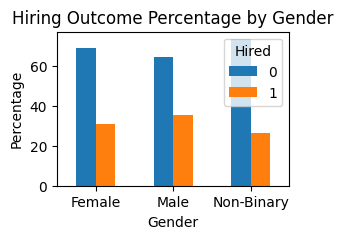

In [12]:
gender_hiring.plot(
    kind="bar",
    figsize=(3,2)
)

plt.title("Hiring Outcome Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Hired")

plt.show()

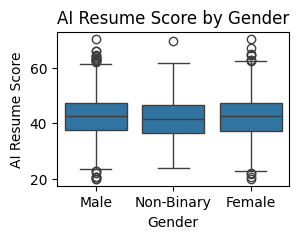

In [13]:
#AI resume score by Gender
plt.figure(figsize=(3,2))

sns.boxplot(
    data=df,
    x="gender",
    y="ai_resume_score"
)

plt.title("AI Resume Score by Gender")
plt.xlabel("Gender")
plt.ylabel("AI Resume Score")

plt.show()

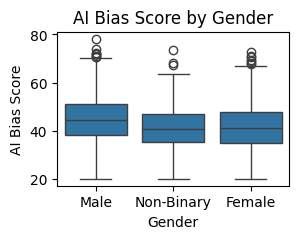

In [14]:
#AI Bias score by Gender
plt.figure(figsize=(3,2))

sns.boxplot(
    data=df,
    x="gender",
    y="ai_bias_score"
)

plt.title("AI Bias Score by Gender")
plt.xlabel("Gender")
plt.ylabel("AI Bias Score")

plt.show()

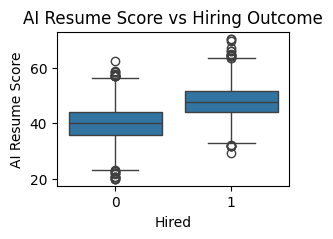

In [15]:
#AI Score VS Hiring(how strongly ai score relate to hiring)
plt.figure(figsize=(3,2))

sns.boxplot(
    data=df,
    x="hired",
    y="ai_resume_score"
)

plt.title("AI Resume Score vs Hiring Outcome")
plt.xlabel("Hired")
plt.ylabel("AI Resume Score")

plt.show()

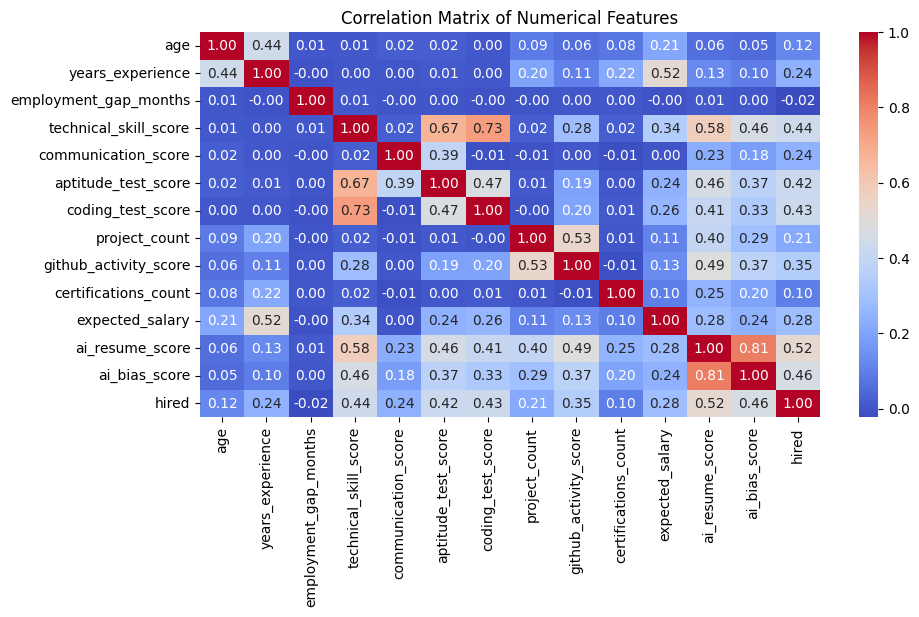

In [16]:
#Correlation Heatmap(main EDA Visualization)
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [17]:
df_working = df.copy()

df_working.to_csv(
    "../results/AI_Hiring_Bias_Working.csv",
    index=False
)

print("Working dataset saved successfully!")
print("Shape:", df_working.shape)

Working dataset saved successfully!
Shape: (5000, 18)


In [18]:
print("Gender groups:")

print(df["gender"].value_counts())

Gender groups:
gender
Male          2609
Female        2135
Non-Binary     256
Name: count, dtype: int64


In [19]:
#Hiring rate by gender
hiring_rate_by_gender = (
    df.groupby("gender")["hired"]
    .mean() * 100
)

print("Hiring rate by gender:")
print(hiring_rate_by_gender)

Hiring rate by gender:
gender
Female        30.913349
Male          35.339210
Non-Binary    26.562500
Name: hired, dtype: float64


In [20]:
#Count of candidates by hiring and gender outcomes
gender_hiring_counts = pd.crosstab(
    df["gender"],
    df["hired"]
)

print(gender_hiring_counts)

hired          0    1
gender               
Female      1475  660
Male        1687  922
Non-Binary   188   68


In [21]:
#AI resume score by gender
#Checks Does the AI assign different resume scores to different gender groups?
ai_score_by_gender = (
    df.groupby("gender")["ai_resume_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(ai_score_by_gender)

            count       mean  median       std   min   max
gender                                                    
Female       2135  42.556440    42.6  7.205737  20.0  70.4
Male         2609  42.498544    42.4  7.229642  20.0  70.2
Non-Binary    256  42.098828    41.6  7.720274  24.0  69.6


In [22]:
#AI bias score by gender
bias_score_by_gender = (
    df.groupby("gender")["ai_bias_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(bias_score_by_gender)

            count       mean  median       std   min   max
gender                                                    
Female       2135  41.351710    41.1  9.302833  20.0  72.6
Male         2609  44.527022    44.3  9.287969  20.0  78.2
Non-Binary    256  41.295313    40.6  9.852221  20.0  73.5


In [23]:
#Comparing qualifications by gender
#Checks if AI scores differ between groups,we need to know whether candidate qualifications also differ
qualification_by_gender = df.groupby("gender")[
    [
        "years_experience",
        "technical_skill_score",
        "communication_score",
        "aptitude_test_score",
        "coding_test_score",
        "project_count",
        "certifications_count"
    ]
].mean()

print(qualification_by_gender)

            years_experience  technical_skill_score  communication_score  \
gender                                                                     
Female              4.387213              68.758033            77.291663   
Male                4.359946              69.097470            77.263549   
Non-Binary          3.912500              69.065625            76.548828   

            aptitude_test_score  coding_test_score  project_count  \
gender                                                              
Female                57.970445          49.855222       4.154567   
Male                  58.101801          49.447604       4.097355   
Non-Binary            58.073047          48.498828       4.125000   

            certifications_count  
gender                            
Female                  1.984543  
Male                    1.994251  
Non-Binary              1.871094  


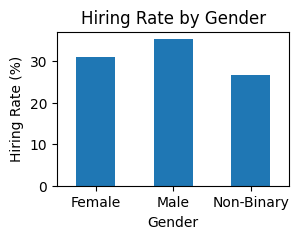

In [24]:
#Hiring rate visulaizations
plt.figure(figsize=(3,2))

hiring_rate_by_gender.plot(kind="bar")

plt.title("Hiring Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Hiring Rate (%)")
plt.xticks(rotation=0)

plt.show()

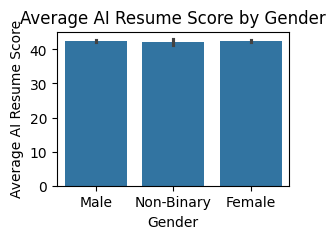

In [25]:
#AI score visualizations
plt.figure(figsize=(3,2))

sns.barplot(
    data=df,
    x="gender",
    y="ai_resume_score"
)

plt.title("Average AI Resume Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average AI Resume Score")

plt.show()

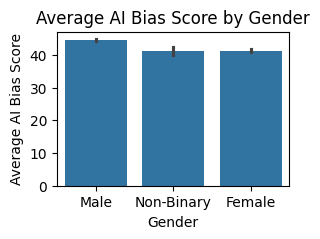

In [26]:
#AI bias score visualizations
plt.figure(figsize=(3,2))

sns.barplot(
    data=df,
    x="gender",
    y="ai_bias_score"
)

plt.title("Average AI Bias Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average AI Bias Score")

plt.show()

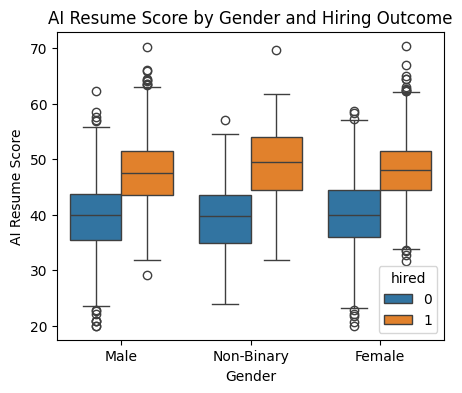

In [27]:
#AI score vs hiring separated by gender(ai score distributions differ between groups and hiring outcomes)
plt.figure(figsize=(5,4))

sns.boxplot(
    data=df,
    x="gender",
    y="ai_resume_score",
    hue="hired"
)

plt.title("AI Resume Score by Gender and Hiring Outcome")
plt.xlabel("Gender")
plt.ylabel("AI Resume Score")

plt.show()

In [28]:
#Selection Rate =
#Number selected
#----------------
#Total candidates

selection_rate = (
    df.groupby("gender")["hired"]
    .mean()
)

print("Selection rate by gender:")
print(selection_rate)

Selection rate by gender:
gender
Female        0.309133
Male          0.353392
Non-Binary    0.265625
Name: hired, dtype: float64


In [29]:
#Demographic parity difference
#A value of 0 means the groups have identical selection rates
#A larger value means a larger observed difference in selection rates
# Fairlearn defines demographic parity difference this way
max_selection = selection_rate.max()
min_selection = selection_rate.min()

demographic_parity_difference = (
    max_selection - min_selection
)

print(
    "Demographic Parity Difference:",
    round(demographic_parity_difference, 4)
)

Demographic Parity Difference: 0.0878


In [30]:
demographic_parity_ratio = (
    min_selection / max_selection
)

print(
    "Demographic Parity Ratio:",
    round(demographic_parity_ratio, 4)
)

Demographic Parity Ratio: 0.7516


In [31]:
from fairlearn.metrics import (
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio
)

y_true = df["hired"]
y_pred = df["hired"]
sensitive_features = df["gender"]

dp_difference = demographic_parity_difference(
    y_true,
    y_pred,
    sensitive_features=sensitive_features
)

dp_ratio = demographic_parity_ratio(
    y_true,
    y_pred,
    sensitive_features=sensitive_features
)

print("Demographic Parity Difference:", round(dp_difference, 4))
print("Demographic Parity Ratio:", round(dp_ratio, 4))

Demographic Parity Difference: 0.0878
Demographic Parity Ratio: 0.7516


In [32]:
#fairness summary
fairness_summary = pd.DataFrame({
    "Selection Rate": selection_rate,
    "Average AI Score": df.groupby("gender")["ai_resume_score"].mean(),
    "Average AI Bias Score": df.groupby("gender")["ai_bias_score"].mean()
})

print(fairness_summary)

                                             Selection Rate  Average AI Score  \
gender                                                                          
Female      <function selection_rate at 0x000001F3F2E21E80>         42.556440   
Male        <function selection_rate at 0x000001F3F2E21E80>         42.498544   
Non-Binary  <function selection_rate at 0x000001F3F2E21E80>         42.098828   

            Average AI Bias Score  
gender                             
Female                  41.351710  
Male                    44.527022  
Non-Binary              41.295313  


In [33]:
#statistical test:here we use Anova because we have more than two gender categories
from scipy.stats import f_oneway

groups = [
    group["ai_resume_score"].dropna().values
    for _, group in df.groupby("gender")
]

anova_result = f_oneway(*groups)

print("ANOVA F-statistic:", anova_result.statistic)
print("ANOVA p-value:", anova_result.pvalue)

ANOVA F-statistic: 0.4568820967273855
ANOVA p-value: 0.6332814489860568


In [34]:
#Age group fairness analysis
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 100],
    labels=["18-25", "26-35", "36-45", "46+"]
)

print(df["age_group"].value_counts().sort_index())

age_group
18-25    1370
26-35    3197
36-45     431
46+         2
Name: count, dtype: int64


In [35]:
#Hiring rate by age group
age_hiring_rate = (
    df.groupby("age_group", observed=True)["hired"]
    .mean() * 100
)

print("Hiring rate by age group:")
print(age_hiring_rate)

Hiring rate by age group:
age_group
18-25    24.963504
26-35    35.001564
36-45    43.851508
46+       0.000000
Name: hired, dtype: float64


In [36]:
#AI score by age group
age_ai_score = (
    df.groupby("age_group", observed=True)["ai_resume_score"]
    .mean()
)

print("Average AI score by age group:")
print(age_ai_score)

Average AI score by age group:
age_group
18-25    41.690365
26-35    42.739881
36-45    43.323666
46+      43.150000
Name: ai_resume_score, dtype: float64


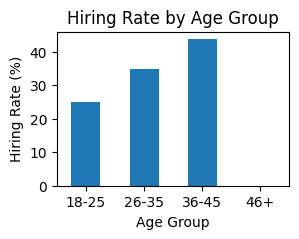

In [37]:
#Age fairness analysis
plt.figure(figsize=(3,2))

age_hiring_rate.plot(kind="bar")

plt.title("Hiring Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Hiring Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [38]:
#ML Model=  For the first ML model, we'll predict hired.
#We'll not use hired itself as a feature, obviously.
#We'll also initially keep ai_resume_score and ai_bias_score out of the predictive features. This makes the model more useful for asking:
#EX: "Which candidate characteristics are associated with the recorded hiring outcome?"
# rather than simply letting an AI score reproduce the hiring decision

#Preparing ML dataset

ml_df = df.copy()

print("ML dataset shape:", ml_df.shape)
print("\nColumns:")
print(ml_df.columns.tolist())


ML dataset shape: (5000, 19)

Columns:
['candidate_id', 'age', 'gender', 'education_level', 'university_tier', 'years_experience', 'employment_gap_months', 'technical_skill_score', 'communication_score', 'aptitude_test_score', 'coding_test_score', 'project_count', 'github_activity_score', 'certifications_count', 'expected_salary', 'ai_resume_score', 'ai_bias_score', 'hired', 'age_group']


In [39]:
# Select features and target

target = "hired"

features = [
    "age",
    "gender",
    "education_level",
    "university_tier",
    "years_experience",
    "employment_gap_months",
    "technical_skill_score",
    "communication_score",
    "aptitude_test_score",
    "coding_test_score",
    "project_count",
    "github_activity_score",
    "certifications_count",
    "expected_salary"
]

X = ml_df[features]
y = ml_df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (5000, 14)
Target shape: (5000,)

Target distribution:
hired
0    3350
1    1650
Name: count, dtype: int64


In [40]:
#Checking the target values

print("Unique target values:")
print(y.unique())

print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

Unique target values:
[0 1]

Target percentages:
hired
0    67.0
1    33.0
Name: proportion, dtype: float64


In [41]:
#Spliting data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 14)
Testing data: (1000, 14)


In [42]:
#here we are defining numerical and categorical features

numeric_features = [
    "age",
    "years_experience",
    "employment_gap_months",
    "technical_skill_score",
    "communication_score",
    "aptitude_test_score",
    "coding_test_score",
    "project_count",
    "github_activity_score",
    "certifications_count",
    "expected_salary"
]

categorical_features = [
    "gender",
    "education_level",
    "university_tier"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 11
Categorical features: 3


In [43]:
#preprocessing pipeline is created

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [44]:
#Using Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression model created!")

Logistic Regression model created!


In [45]:
#Training the Logistic Regression

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [46]:
#Make predictions with logistic regression model

y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated!")
print(y_pred_logistic[:20])

Predictions generated!
[0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0]


In [47]:
#here we are evaluating Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
--------------------------------
Accuracy : 0.828
Precision: 0.7582
Recall   : 0.703
F1 Score : 0.7296

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       670
           1       0.76      0.70      0.73       330

    accuracy                           0.83      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.83      0.83      0.83      1000



Confusion Matrix:
[[596  74]
 [ 98 232]]


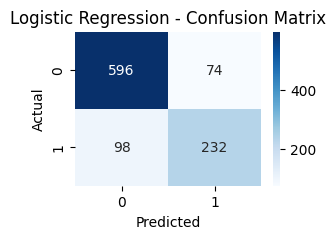

In [48]:
#confusion Matrix

from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

#Visualizing it
plt.figure(figsize=(3,2))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
#Now we are using Random forest
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

print("Random Forest model created!")

Random Forest model created!


In [50]:
#Training Random Forest

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

#Random Forest predictions

y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated!")
print(y_pred_rf[:20])

Random Forest training completed!
Predictions generated!
[0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0]


In [51]:
#Evaluating Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
--------------------------------
Accuracy : 0.818
Precision: 0.7662
Recall   : 0.6455
F1 Score : 0.7007

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       670
           1       0.77      0.65      0.70       330

    accuracy                           0.82      1000
   macro avg       0.80      0.77      0.78      1000
weighted avg       0.81      0.82      0.81      1000



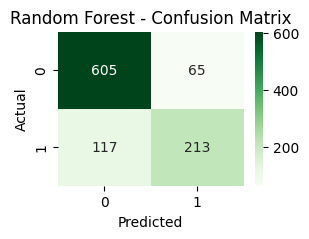

In [52]:
#Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(3,2))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.828   0.758170  0.703030  0.729560
1        Random Forest     0.818   0.766187  0.645455  0.700658


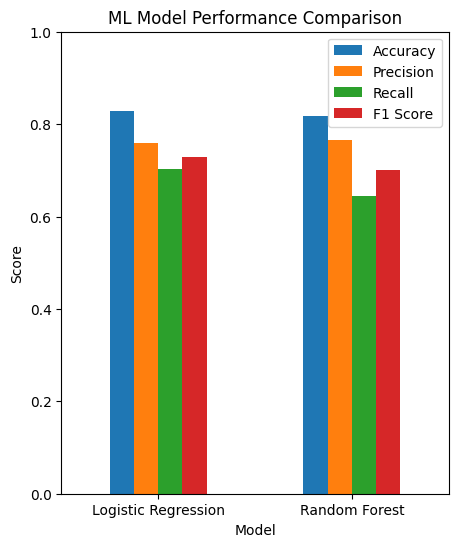

In [53]:
#Compare the both created ML models(logistic regression nd random forest)

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_rf
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf
    ]
})

print(model_comparison)

#now Visulaizing themmm
model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(5,6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

Number of transformed features: 20
['num__age' 'num__years_experience' 'num__employment_gap_months'
 'num__technical_skill_score' 'num__communication_score'
 'num__aptitude_test_score' 'num__coding_test_score' 'num__project_count'
 'num__github_activity_score' 'num__certifications_count'
 'num__expected_salary' 'cat__gender_Female' 'cat__gender_Male'
 'cat__gender_Non-Binary' "cat__education_level_Bachelor's"
 "cat__education_level_Master's" 'cat__education_level_PhD'
 'cat__university_tier_Tier 1' 'cat__university_tier_Tier 2'
 'cat__university_tier_Tier 3']
                        Feature  Importance
6        num__coding_test_score    0.138556
3    num__technical_skill_score    0.132625
5      num__aptitude_test_score    0.132283
8    num__github_activity_score    0.116063
4      num__communication_score    0.092052
1         num__years_experience    0.089398
10         num__expected_salary    0.077556
0                      num__age    0.045062
7            num__project_count    0.0

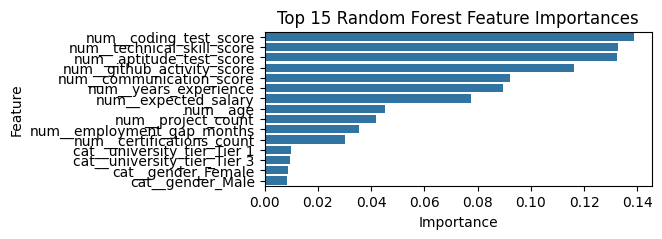

In [54]:
#Random forest features

preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names)

# Get Random Forest feature importance
rf_classifier = random_forest_model.named_steps["classifier"]

importance = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

#Visulaizing them
# Top 15 feature importances

top_features = feature_importance.head(15)

plt.figure(figsize=(5,2))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [55]:
#Saving the worked models comparison

model_comparison.to_csv(
    "../results/ML_Model_Comparison.csv",
    index=False
)

feature_importance.to_csv(
    "../results/Random_Forest_Feature_Importance.csv",
    index=False
)

print("ML results saved successfully!")

ML results saved successfully!


In [56]:
#ROC-AUC scores

from sklearn.metrics import roc_auc_score

# Probability of class 1 = hired
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Results")
print("-------------------------")
print("Logistic Regression:", round(auc_logistic, 4))
print("Random Forest      :", round(auc_rf, 4))

ROC-AUC Results
-------------------------
Logistic Regression: 0.9008
Random Forest      : 0.8755


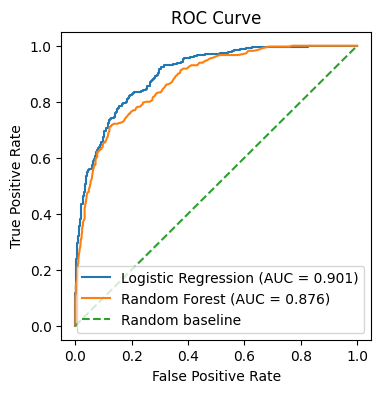

In [57]:
#ROC Curve

from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(4,4))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [58]:
#Create prediction results

results_df = X_test.copy()

results_df["actual_hired"] = y_test.values
results_df["logistic_prediction"] = y_pred_logistic
results_df["random_forest_prediction"] = y_pred_rf

results_df["logistic_probability"] = y_prob_logistic
results_df["random_forest_probability"] = y_prob_rf

print(results_df.head())

      age  gender education_level university_tier  years_experience  \
2779   39    Male      Bachelor's          Tier 2               7.1   
2597   27    Male      Bachelor's          Tier 2               1.5   
65     39  Female      Bachelor's          Tier 3               6.1   
3706   32  Female        Master's          Tier 2               5.2   
2320   23  Female      Bachelor's          Tier 2               4.2   

      employment_gap_months  technical_skill_score  communication_score  \
2779                    5.5                   53.2                 74.7   
2597                    0.0                   87.6                 80.4   
65                      0.1                   75.2                 73.1   
3706                    2.7                   73.6                 65.2   
2320                    0.0                   74.5                 69.7   

      aptitude_test_score  coding_test_score  project_count  \
2779                 44.5               24.7              5

In [59]:
#Predicting the hiring rate by gender

predicted_hiring_by_gender = results_df.groupby("gender")[
    [
        "actual_hired",
        "logistic_prediction",
        "random_forest_prediction"
    ]
].mean() * 100

print(predicted_hiring_by_gender)

            actual_hired  logistic_prediction  random_forest_prediction
gender                                                                 
Female         29.466357            27.842227                 26.682135
Male           36.831683            34.059406                 29.702970
Non-Binary     26.562500            21.875000                 20.312500


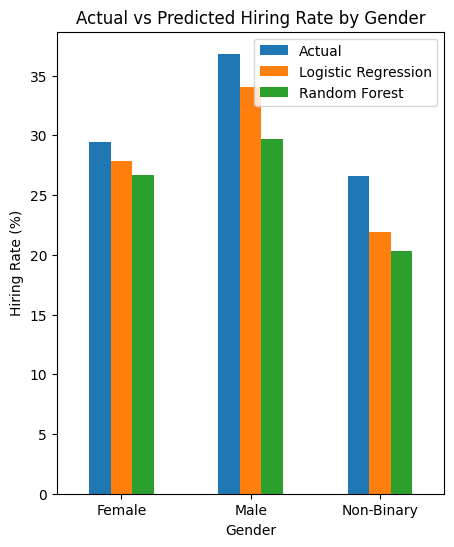

In [60]:
#Ploting the acutal vs predicted hiring rates

predicted_hiring_by_gender.plot(
    kind="bar",
    figsize=(5,6)
)

plt.title("Actual vs Predicted Hiring Rate by Gender")
plt.ylabel("Hiring Rate (%)")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(
    [
        "Actual",
        "Logistic Regression",
        "Random Forest"
    ]
)

plt.show()

In [61]:
#Calculating predicted selection rates
#Selection rates for model predictions
actual_selection_rate = (
    results_df.groupby("gender")["actual_hired"].mean()
)

logistic_selection_rate = (
    results_df.groupby("gender")["logistic_prediction"].mean()
)

rf_selection_rate = (
    results_df.groupby("gender")["random_forest_prediction"].mean()
)

print("Actual Selection Rate:")
print(actual_selection_rate)

print("\nLogistic Regression Selection Rate:")
print(logistic_selection_rate)

print("\nRandom Forest Selection Rate:")
print(rf_selection_rate)

Actual Selection Rate:
gender
Female        0.294664
Male          0.368317
Non-Binary    0.265625
Name: actual_hired, dtype: float64

Logistic Regression Selection Rate:
gender
Female        0.278422
Male          0.340594
Non-Binary    0.218750
Name: logistic_prediction, dtype: float64

Random Forest Selection Rate:
gender
Female        0.266821
Male          0.297030
Non-Binary    0.203125
Name: random_forest_prediction, dtype: float64


In [62]:
#Difference btw highest nd lowest selection rates are found here
#Demographic Parity Difference

actual_dp_difference = (
    actual_selection_rate.max()
    - actual_selection_rate.min()
)

logistic_dp_difference = (
    logistic_selection_rate.max()
    - logistic_selection_rate.min()
)

rf_dp_difference = (
    rf_selection_rate.max()
    - rf_selection_rate.min()
)

print("Actual DP Difference:",
      round(actual_dp_difference, 4))

print("Logistic Regression DP Difference:",
      round(logistic_dp_difference, 4))

print("Random Forest DP Difference:",
      round(rf_dp_difference, 4))

Actual DP Difference: 0.1027
Logistic Regression DP Difference: 0.1218
Random Forest DP Difference: 0.0939


In [63]:
#Demographic Parity Ratio

actual_dp_ratio = (
    actual_selection_rate.min()
    / actual_selection_rate.max()
)

logistic_dp_ratio = (
    logistic_selection_rate.min()
    / logistic_selection_rate.max()
)

rf_dp_ratio = (
    rf_selection_rate.min()
    / rf_selection_rate.max()
)

print("Actual DP Ratio:",
      round(actual_dp_ratio, 4))

print("Logistic Regression DP Ratio:",
      round(logistic_dp_ratio, 4))

print("Random Forest DP Ratio:",
      round(rf_dp_ratio, 4))

Actual DP Ratio: 0.7212
Logistic Regression DP Ratio: 0.6423
Random Forest DP Ratio: 0.6839


In [64]:
#WE can see ai score vs hiring outcomes 

ai_analysis = df.groupby("hired")[
    [
        "ai_resume_score",
        "ai_bias_score"
    ]
].mean()

print(ai_analysis)



       ai_resume_score  ai_bias_score
hired                                
0            39.840299      39.947224
1            47.908485      49.215333


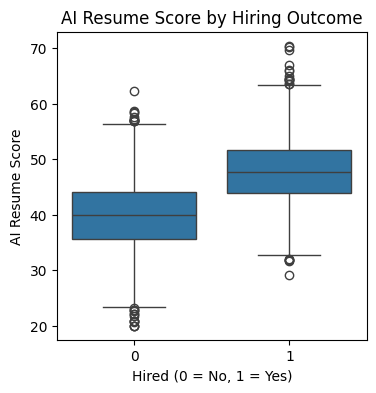

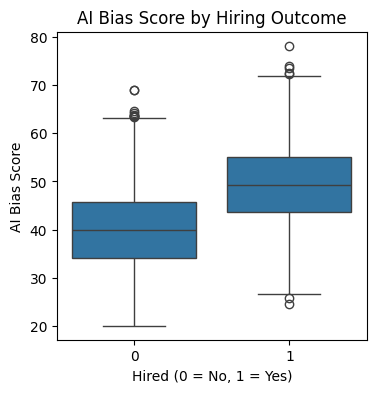

In [65]:
#Visualizing AI Resume Score by Hiring Outcome

plt.figure(figsize=(4,4))

sns.boxplot(
    data=df,
    x="hired",
    y="ai_resume_score"
)

plt.title("AI Resume Score by Hiring Outcome")
plt.xlabel("Hired (0 = No, 1 = Yes)")
plt.ylabel("AI Resume Score")

plt.show()

# AI Bias Score by Hiring Outcome

plt.figure(figsize=(4,4))

sns.boxplot(
    data=df,
    x="hired",
    y="ai_bias_score"
)

plt.title("AI Bias Score by Hiring Outcome")
plt.xlabel("Hired (0 = No, 1 = Yes)")
plt.ylabel("AI Bias Score")

plt.show()

In [66]:
#Gender-wise AI score and hiring

gender_ai_analysis = df.groupby("gender").agg(
    hiring_rate=("hired", "mean"),
    average_ai_score=("ai_resume_score", "mean"),
    average_bias_score=("ai_bias_score", "mean")
)

gender_ai_analysis["hiring_rate"] *= 100

print(gender_ai_analysis)

            hiring_rate  average_ai_score  average_bias_score
gender                                                       
Female        30.913349         42.556440           41.351710
Male          35.339210         42.498544           44.527022
Non-Binary    26.562500         42.098828           41.295313


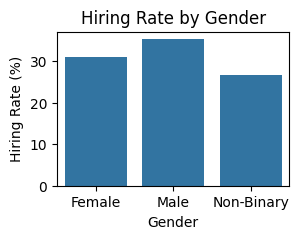

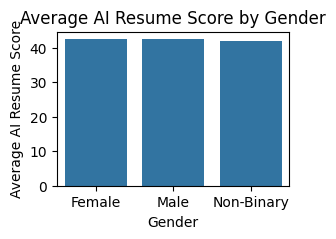

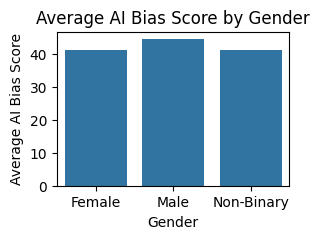

In [67]:
# Hiring rate by gender
plt.figure(figsize=(3,2))

sns.barplot(
    data=gender_ai_analysis.reset_index(),
    x="gender",
    y="hiring_rate"
)

plt.title("Hiring Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Hiring Rate (%)")

plt.show()

#AI Resume Score by gender
plt.figure(figsize=(3,2))

sns.barplot(
    data=gender_ai_analysis.reset_index(),
    x="gender",
    y="average_ai_score"
)

plt.title("Average AI Resume Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average AI Resume Score")

plt.show()

#AI Bias Score by gender
plt.figure(figsize=(3,2))

sns.barplot(
    data=gender_ai_analysis.reset_index(),
    x="gender",
    y="average_bias_score"
)

plt.title("Average AI Bias Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average AI Bias Score")

plt.show()

In [68]:
#Checking whether grps differ in ai scores
#ANOVA result
print("ANOVA F-statistic:",
      round(anova_result.statistic, 4))

print("ANOVA p-value:",
      round(anova_result.pvalue, 6))

ANOVA F-statistic: 0.4569
ANOVA p-value: 0.633281


### ANOVA Interpretation

ANOVA was used to test whether mean AI resume scores differed
across gender groups. A statistically significant result would
indicate evidence of a difference in group means, but would not
by itself establish the cause of that difference.

In [69]:
#Final fairness summary

final_fairness_summary = pd.DataFrame({
    "Metric": [
        "Actual Selection Rate Difference",
        "Actual Selection Rate Ratio",
        "Logistic Prediction Difference",
        "Logistic Prediction Ratio",
        "Random Forest Prediction Difference",
        "Random Forest Prediction Ratio",
        "ANOVA p-value"
    ],
    "Value": [
        actual_dp_difference,
        actual_dp_ratio,
        logistic_dp_difference,
        logistic_dp_ratio,
        rf_dp_difference,
        rf_dp_ratio,
        anova_result.pvalue
    ]
})

print(final_fairness_summary)

                                Metric     Value
0     Actual Selection Rate Difference  0.102692
1          Actual Selection Rate Ratio  0.721186
2       Logistic Prediction Difference  0.121844
3            Logistic Prediction Ratio  0.642260
4  Random Forest Prediction Difference  0.093905
5       Random Forest Prediction Ratio  0.683854
6                        ANOVA p-value  0.633281


In [70]:
#Final ML summary
final_ml_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_rf
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf
    ],
    "ROC-AUC": [
        auc_logistic,
        auc_rf
    ]
})

print(final_ml_summary)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression     0.828   0.758170  0.703030  0.729560  0.900751
1        Random Forest     0.818   0.766187  0.645455  0.700658  0.875527


In [71]:
#saving all data evaluated till now

final_ml_summary.to_csv(
    "../results/Final_ML_Summary.csv",
    index=False
)

final_fairness_summary.to_csv(
    "../results/Final_Fairness_Summary.csv",
    index=False
)

gender_ai_analysis.to_csv(
    "../results/Gender_AI_Fairness_Analysis.csv"
)

results_df.to_csv(
    "../results/Model_Predictions.csv",
    index=False
)

print("All results saved successfully!")

All results saved successfully!


In [72]:
#Display final project findings

print("=" * 60)
print("AI HIRING BIAS - FINAL ANALYSIS")
print("=" * 60)

print("\nMODEL PERFORMANCE")
print(final_ml_summary.to_string(index=False))

print("\nFAIRNESS METRICS")
print(final_fairness_summary.to_string(index=False))

print("\nGENDER-WISE AI ANALYSIS")
print(gender_ai_analysis)

print("\nANOVA")
print("F-statistic:", round(anova_result.statistic, 4))
print("p-value:", round(anova_result.pvalue, 6))

print("\nAnalysis completed.")

AI HIRING BIAS - FINAL ANALYSIS

MODEL PERFORMANCE
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression     0.828   0.758170 0.703030  0.729560 0.900751
      Random Forest     0.818   0.766187 0.645455  0.700658 0.875527

FAIRNESS METRICS
                             Metric    Value
   Actual Selection Rate Difference 0.102692
        Actual Selection Rate Ratio 0.721186
     Logistic Prediction Difference 0.121844
          Logistic Prediction Ratio 0.642260
Random Forest Prediction Difference 0.093905
     Random Forest Prediction Ratio 0.683854
                      ANOVA p-value 0.633281

GENDER-WISE AI ANALYSIS
            hiring_rate  average_ai_score  average_bias_score
gender                                                       
Female        30.913349         42.556440           41.351710
Male          35.339210         42.498544           44.527022
Non-Binary    26.562500         42.098828           41.295313

ANOVA
F-statistic: 0.4569
p-